In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,recall_score, precision_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, PrecisionRecallDisplay
from src.data.load_data import import_dataset
from src.config import features, features_cat, features_num, target
from src.preprocess import churn_mapped, create_preprocessor, train_test, total_charges

Config inicial

In [2]:
df = import_dataset(r"..\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"] = total_charges(df)
X = df[features]
y = churn_mapped(df, target)


X_train, X_test, y_train, y_test = train_test(X,y)

preprocessor = create_preprocessor(features_num, features_cat)

In [3]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced',random_state=42, max_iter=1000))
])
pipeline_lr.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [4]:
features_names = pipeline_lr.named_steps[
    'preprocessor'
].get_feature_names_out()

coef = pipeline_lr.named_steps[
    'model'
].coef_[0]

interpretação das features no modelo

In [8]:
coef_df = pd.DataFrame({
    "feature": features_names,
    "coef": coef
})

coef_df.sort_values(
    "coef",
    ascending=False
)


,feature,coef
17,cat__InternetService_Fiber optic,0.716960
37,cat__Contract_Month-to-month,0.668239
1,num__TotalCharges,0.472177
36,cat__StreamingMovies_Yes,0.283083
33,cat__StreamingTV_Yes,0.269648
44,cat__PaymentMethod_Electronic check,0.244307
19,cat__OnlineSecurity_No,0.205342
28,cat__TechSupport_No,0.170736
15,cat__MultipleLines_Yes,0.138134
41,cat__PaperlessBilling_Yes,0.081393


A partir dos valores de coeficiente retornado pelo modelo de Regressão Logistica, observamos que, quanto maior o valor do coeficiente, maior a chance de Churn do cliente, por feature. Nesse sentido, temos que features como InternetService - FiberOptic, contratos mes a mes, etc tendem a aumentar a probabilidade de Churn. Já Contratos mais longos, tempo de relacionamento, tendem a diminuir a  probabiliadde de Churn

# SHAP

Os valores SHAP tem o intuito de explicar o resultado do modelo utilizando cada features, onde mostra qual a contribuição de cada feature para o resultado final, no nosso caso, se o cliente terá maior ou menor probabilidade de Churn

In [ ]:
import shap 

In [12]:
model = pipeline_lr.named_steps['model']
X_train_transformed = preprocessor.transform(X_train)

In [16]:
explainer = shap.Explainer(
    model,
    X_train_transformed
)
shap_values = explainer(X_train_transformed)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


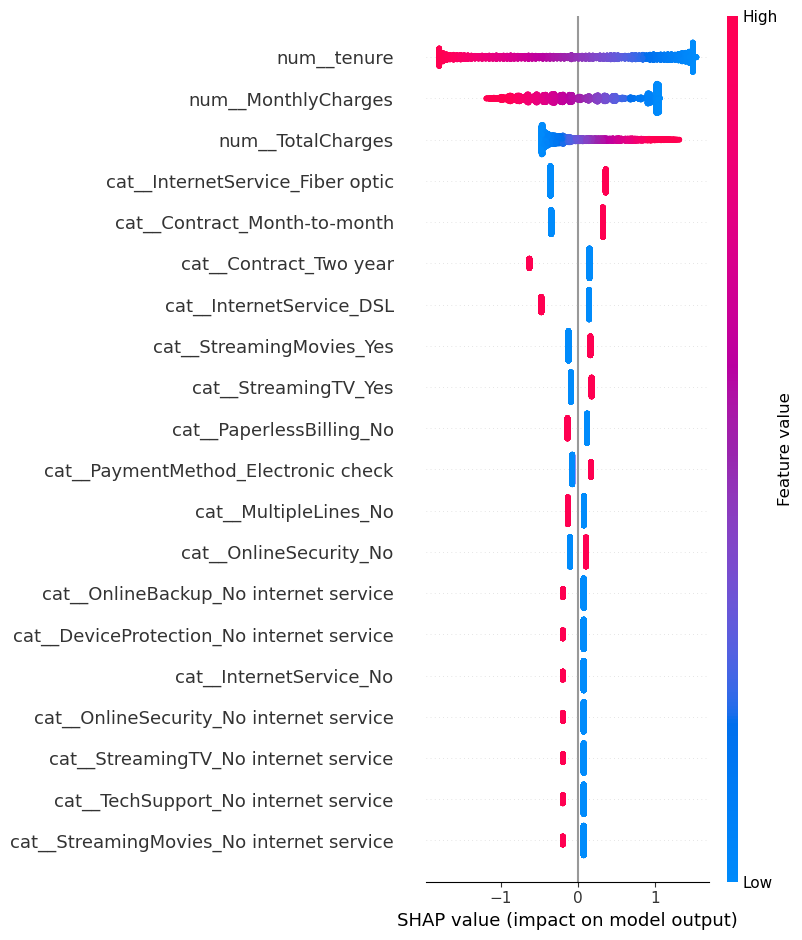

In [18]:
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names = features_names
)


Já observando a analise de SHAP, temos que, ao aumentarmos o valor do eixo Y, verificamos as principais features que influenciam diretamente no Churn. Quando vemos o eixo X, temos qual é o grau de influencia dessas features, sendo quem, valores positivos (direita), são valores que influenciam para o Churn do cliente e valores negativos (esqueda), para o não-Churn. A cor da feature mostra o valor da feature, sendo azul para valores baixos e vermelho para valores altos.    

Interpretando a primeira linha do grafico, temos que a feature "tenure" (tempo de relacionamento) possui alto grau de influencia no Churn. Ao verificarmos o comportamento no eixo X, temos que, com baixos valores de "tenure" (cor azul), a probabilidade de Churn é maior, ou seja, clientes com baixo tempo de relacionamento tendem a dar Churn com maior facilidade. O contrario também é verdadeiro, onde clientes com maior tempo de relacionamento (cor vermelha), tendem a continuarem retidos e fidelizados.

Já em Total Charges, por exemplo, vemos que quanto maior o valor total pago, maior a tendencia de Churn, tendo um comportamento inverso ao Tenure.